### Calculating the Spectral Fidelity


Instead of just computing the error in the trajectory. We are also interested in seing if the neural ODE has managed to capture the spectral properties of the system. To do this we will compute the spectral fidelity between the true and predicted trajectories.

In our case we consider spectral fidelity in terms of the eigenvalues of the system. We will compute the eigenvalues of the true and predicted trajectories and then compute error (MAE or MSE)between them - across time. 

Specifically, consider a system that has $n$ eigenvalues, $\lambda_1, \lambda_2, \ldots, \lambda_n$ at time $t$.
Using automatic differentiation we can estimate the computed eigenvalues of the system at each time step, $\hat{\lambda}_1, \hat{\lambda}_2, \ldots, \hat{\lambda}_n$.
We are then interested in giving one error per eigenvalue. 

$$E_i = \frac{1}{N_T}\sum_{k=1}^{N_T}|\lambda_i(t_k) - \hat{\lambda}_i(t_k)|$$


Here we consider the eigenvalues in a sorted manner, $\lambda_1 \leq \lambda_2 \leq \ldots \leq \lambda_n$ and $\hat{\lambda}_1 \leq \hat{\lambda}_2 \leq \ldots \leq \hat{\lambda}_n$.

#### Computing the learned eigenvalues
Let the (autonomous) Neural ODE be 
$$\frac{dx}{dt} = F_\theta(x)$$

The learned Jacobian is then 
$$J_\theta(x) = \frac{\partial F_\theta(x)}{\partial x}$$

What do I need:
1. Model that takes in x and outputs F(x)
2. Trajectory of x(t) and F(x(t))
3. Real eigenvalues. 

In [57]:
### Compute true solution. 

### Define eigenvalues
using ForwardDiff, LinearAlgebra
include("stiffnet/run.jl")

In [71]:
(; ctx, cfg, θ) = main("rober")
eigvals_true, eigvals_learned = eigenvalues(ctx, θ, absolute=true)

rober  d=3 tlen=50 profile=fast seed=123  solver=Rodas5  N=318
derivative matching [4s]  fitloss=6.07e-5
  [derivative matching]  nrmse=0.005161  l2=0.02677
  AMR 1/3: M=168  err=6.56e-5  nrmse=0.00976  best=0.00516  refined=14
  AMR 2/3: M=200  err=2.35e-12  nrmse=0.00185  best=0.00185  refined=9
  AMR 3/3: M=240  err=3.13e-12  nrmse=0.00145  best=0.00145  refined=0
collocation [11024s]
  [final]  nrmse=0.001451  l2=2.315e-5
saved rober_fit.png
saved rober_spectral_fit.png


([0.04 1.2535443050857555 … 6261.151735785945 6752.095452818321; 0.0 0.040215831236512393 … 0.0015704909184690312 0.0010760932787861942; 0.0 1.0487291655795422e-19 … 2.8695426951485294e-16 4.2243877159240884e-17], [2355.6201909498927 717.9059440735439 … 5.326627700610685 6.203045815302614; 0.2636140282072131 1.763282747478924 … 0.001569205004161279 0.0010954995743958828; 0.001429961723373146 0.00032560983394436726 … 0.0008276732638457028 0.0006102156762162265])

In [62]:
eigvals_true

2×151 Matrix{Float64}:
 299.997       299.998      299.991       …  207.862      195.291
   0.00333337    0.0033969    0.00479332       0.0094394    0.0103641

In [74]:
function vanderpol_true_eigenvalues(
    x_data::AbstractMatrix{<:Real};
    μ::Real = 100.0,
)
    size(x_data, 1) == 2 ||
        throw(DimensionMismatch("x_data must have size (2, Nsteps)"))

    Nsteps = size(x_data, 2)
    eigenvalues = Matrix{ComplexF64}(undef, 2, Nsteps)

    for k in axes(x_data, 2)
        x₁ = x_data[1, k]
        x₂ = x_data[2, k]

        J = [
            0.0                  1.0
            -1.0 - 2μ * x₁ * x₂  μ * (1.0 - x₁^2)
        ]

        eigenvalues[:, k] = eigvals(J)
    end

    return eigenvalues
end

"""
    rober_true_eigenvalues(y_data)

Compute the three true Jacobian eigenvalues of the Robertson ODE
at every state.

# Arguments
- `y_data`: Array of size `(3, Nsteps)`, where each column is
  `[y₁, y₂, y₃]`.

# Returns
A `3 × Nsteps` complex matrix. The rows correspond to
`λ₀ = 0`, `λ₋`, and `λ₊`.
"""
function rober_true_eigenvalues(y_data::AbstractMatrix{<:Real})
    size(y_data, 1) == 3 ||
        throw(DimensionMismatch("y_data must have size (3, Nsteps)"))

    k1 = 0.04
    k2 = 3e7
    k3 = 1e4

    Nsteps = size(y_data, 2)
    eigenvalues = Matrix{ComplexF64}(undef, 3, Nsteps)

    for k in axes(y_data, 2)
        y2 = y_data[2, k]
        y3 = y_data[3, k]

        τ = -k1 - 2k2 * y2 - k3 * y3
        discriminant = τ^2 - 8k2 * y2 * (k1 + k3 * y2)

        root = sqrt(complex(discriminant))

        λ_minus = (τ - root) / 2
        λ_plus  = (τ + root) / 2

        eigenvalues[:, k] .= (0.0, λ_minus, λ_plus)
    end

    return eigenvalues
end

rober_true_eigenvalues

In [75]:
# true_vdp_eigenvalues = abs.(vanderpol_true_eigenvalues(ctx.Ydata; μ=100))
true_rober_eigenvalues = abs.(rober_true_eigenvalues(ctx.Ydata))

3×50 Matrix{Float64}:
 0.0   0.0        0.0        0.0        …     0.0            0.0
 0.04  1.25354    3.16729    6.08917       6261.15        6752.1
 0.0   0.0402158  0.0405348  0.0410219        0.00157049     0.00107609

In [64]:
using Plots

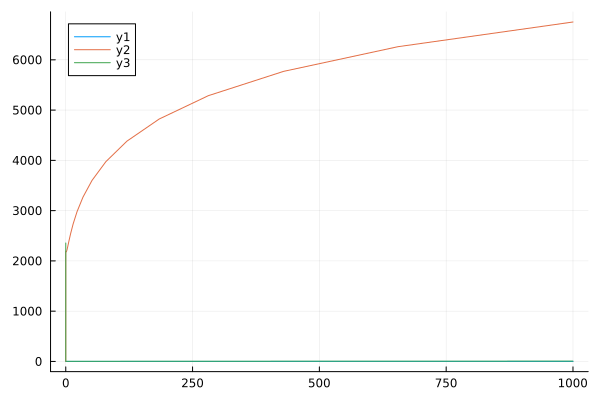

In [80]:
plot(ctx.tsteps, true_rober_eigenvalues[1,:])
plot!(ctx.tsteps, eigvals_true[1,:])
plot!(ctx.tsteps, eigvals_learned[1,:])

In [53]:
function eigenvalues_model(ctx, θ)
    F_learned(x) = f_theta(ctx, x, θ)

    eigenvalues_array = zeros(ComplexF64, size(ctx.Ydata))

    for i in 1:size(ctx.Ydata)[2]
        y = ctx.Ydata[:, i]
        J = ForwardDiff.jacobian(F_learned, y)
        eigenvalues_array[:, i] = sort(eigvals(J), by = abs, rev = true)
    end 
    
    return eigenvalues_array
end 

function eigenvalues_true(ctx, θ)
    F_learned(x) = (du = similar(x); ctx.spec.true_ode!(du, x, nothing, zero(eltype(x))); du)

    eigenvalues_array = zeros(ComplexF64, size(ctx.Ydata))

    for i in 1:size(ctx.Ydata)[2]
        y = ctx.Ydata[:, i]
        J = ForwardDiff.jacobian(F_learned, y)
        eigenvalues_array[:, i] = sort(eigvals(J), by = abs, rev = true)
    end 
    
    return eigenvalues_array
end 

function eigenvalues(ctx, θ; absolute=false)
    F_true(x) = (du = similar(x); ctx.spec.true_ode!(du, x, nothing, zero(eltype(x))); du)
    F_learned(x) = f_theta(ctx, x, θ)


    eigenvalues_true = zeros(ComplexF64, size(ctx.Ydata))
    eigenvalues_learned = zeros(ComplexF64, size(ctx.Ydata))

    for i in 1:size(ctx.Ydata)[2]
        y = ctx.Ydata[:, i]
        J_true = ForwardDiff.jacobian(F_true, y)
        eigenvalues_true[:, i] = sort(eigvals(J_true), by = abs, rev = true)
        J_learned = ForwardDiff.jacobian(F_learned, y)
        eigenvalues_learned[:, i] = sort(eigvals(J_learned), by = abs, rev = true)
    end 
    
    if absolute
        eigenvalues_true = abs.(eigenvalues_true)
        eigenvalues_learned = abs.(eigenvalues_learned)
    end

    return eigenvalues_true, eigenvalues_learned
end 

eigenvalues (generic function with 3 methods)

In [54]:
eigvals_true, eigvals_learned = eigenvalues(ctx, θ, absolute=true)

([0.04 1.2535443050857555 … 6261.151735785945 6752.095452818321; 0.0 0.040215831236512393 … 0.0015704909184690312 0.0010760932787861942; 0.0 1.0487291655795422e-19 … 2.8695426951485294e-16 4.2243877159240884e-17], [2440.5622360277393 1890.7119651424605 … 4.081002161596523 4.153845676971375; 0.36825493512518426 0.7132423436252993 … 0.001381502145315568 0.0008293400629838245; 0.07268835471687338 0.06337012441024695 … 0.00032371714512714295 0.00025439729164985017])

In [55]:
#plot eigenvalues